# CT / MR simulators

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.ndimage as ndi

# Task 1: Tomographic image simulator

CT images are reconstructed (at least in the basic version) using the Radon transform and its inverse. In python, the skimage library provides these transforms already implemented 
(skimage.transform.radon for the transform, skimage.transform.iradon for the inverse)

Use these functions to build a "CT simulator". 

Take as input image the "shepp-logan" phantom (from skimage.data import shepp_logan_phantom, which is a function that takes no input and returns a 400x400 image). 

Resample it to lower resolution using skimage.transform.resize to the shape you want (e.g. 128x128). Do you like the output? If not, read the help and think about the anti_aliasing parameter setting. This will be your test image for the next experiences.

To simulate the CT scan, create a function that takes in input the test image, transforms it in sinogram space using a vector of projection angles, adds gaussian noise to it (standard deviation as input) and then reconstruct the image using iradon.

Initially, in this simulator, have the function display a figure with 2 subplot, the original sinogram with no noise and the sinogram with noise added

First, do the reconstruction with no noise (and display it). Remember that sampling from 0 to 180 degrees is sufficient. But how many "steps" do you need? Does this depend on the number of pixels you used in input? Try that!!

Then try different values of noise and see how much higher can you go with noise and still see the output


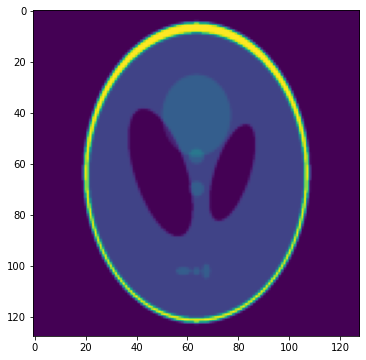

In [3]:
import skimage.data
from skimage.transform import radon, iradon
nPix = 128
plt.figure(figsize=(6,6))
immFull = skimage.data.shepp_logan_phantom()
imm = skimage.transform.resize(immFull,(nPix,nPix),anti_aliasing=True)
plt.imshow(imm)

In [4]:
help (skimage.transform.resize)

Help on function resize in module skimage.transform._warps:

resize(image, output_shape, order=None, mode='reflect', cval=0, clip=True, preserve_range=False, anti_aliasing=None, anti_aliasing_sigma=None)
    Resize image to match a certain size.
    
    Performs interpolation to up-size or down-size N-dimensional images. Note
    that anti-aliasing should be enabled when down-sizing images to avoid
    aliasing artifacts. For downsampling with an integer factor also see
    `skimage.transform.downscale_local_mean`.
    
    Parameters
    ----------
    image : ndarray
        Input image.
    output_shape : iterable
        Size of the generated output image `(rows, cols[, ...][, dim])`. If
        `dim` is not provided, the number of channels is preserved. In case the
        number of input channels does not equal the number of output channels a
        n-dimensional interpolation is applied.
    
    Returns
    -------
    resized : ndarray
        Resized version of the input.
 

In [5]:
help (radon)

Help on function radon in module skimage.transform.radon_transform:

radon(image, theta=None, circle=True, *, preserve_range=False)
    Calculates the radon transform of an image given specified
    projection angles.
    
    Parameters
    ----------
    image : array_like
        Input image. The rotation axis will be located in the pixel with
        indices ``(image.shape[0] // 2, image.shape[1] // 2)``.
    theta : array_like, optional
        Projection angles (in degrees). If `None`, the value is set to
        np.arange(180).
    circle : boolean, optional
        Assume image is zero outside the inscribed circle, making the
        width of each projection (the first dimension of the sinogram)
        equal to ``min(image.shape)``.
    preserve_range : bool, optional
        Whether to keep the original range of values. Otherwise, the input
        image is converted according to the conventions of `img_as_float`.
        Also see https://scikit-image.org/docs/dev/user_guide/

In [6]:
128*np.sqrt(2)

181.01933598375618

Try adding a small square in the corner to see the effect of using "circle=False" or True

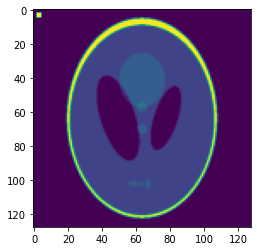

In [7]:
imm[2:5,2:5] = 1
plt.imshow(imm)

(182, 180)


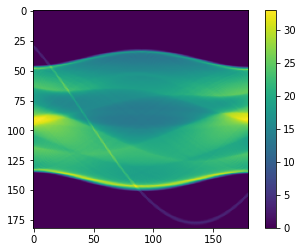

In [10]:
sinoT = radon(imm,circle=False)
print(sinoT.shape)
plt.imshow(sinoT)
plt.colorbar()

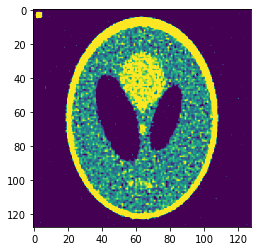

In [12]:
sinoNoisy = sinoT + np.random.normal(0,1,sinoT.shape)
immRecon = iradon(sinoNoisy,circle=False)
plt.imshow(immRecon,vmin=.1,vmax=.3)

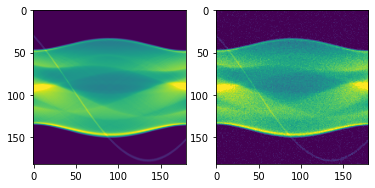

In [13]:
plt.figure()
plt.subplot(121)
plt.imshow(sinoT,vmin=0,vmax=30)
plt.subplot(122)
plt.imshow(sinoNoisy,vmin=0,vmax=30)

In [14]:
def ctSim (inpImage,thetaVect,noiseLev,show=False):
    sino_ = radon(inpImage,thetaVect,circle=False)
    if show:
        plt.figure(figsize=(10,6))
        plt.subplot(121)
        plt.imshow(sino_)
    
    sino_ = sino_+np.random.normal(0,noiseLev,sino_.shape)
    if show:
        plt.subplot(122)
        plt.imshow(sino_)
    outImm = iradon(sino_,thetaVect,circle=False,filter_name='ramp')
    return outImm

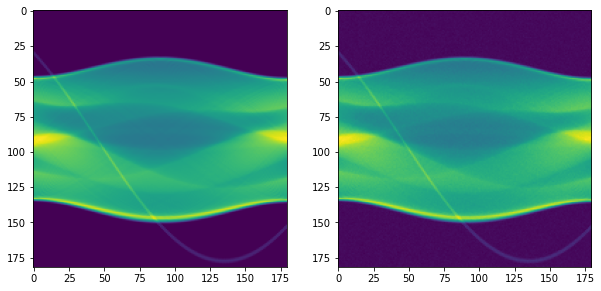

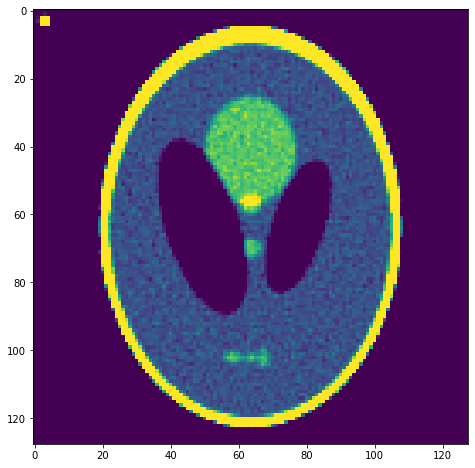

In [15]:
reconIm = ctSim(imm,np.arange(0,180,1),.2,show=True)
plt.figure(figsize=(8,8))
plt.imshow(reconIm,vmin=0.15,vmax=0.35)

### 64x64 image

(-0.5, 63.5, 63.5, -0.5)

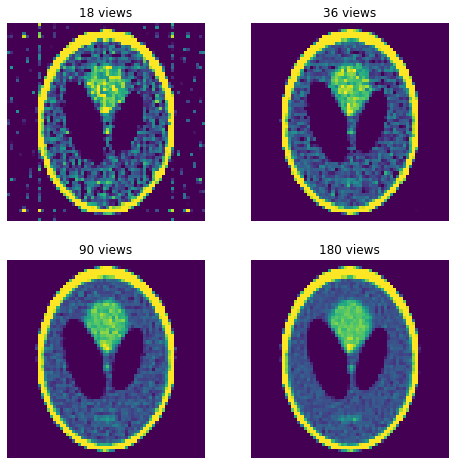

In [17]:
nPix = 64
imm64 = skimage.transform.resize(immFull,(nPix,nPix),anti_aliasing=True)
plt.figure(figsize=(8,8))
plt.subplot(221)
plt.title('18 views')
plt.imshow(ctSim(imm64,np.arange(0,180,10),.2),vmin=0.15,vmax=0.35)
plt.axis('off')
plt.subplot(222)
plt.title('36 views')
plt.imshow(ctSim(imm64,np.arange(0,180,5),.2),vmin=0.15,vmax=0.35)
plt.axis('off')
plt.subplot(223)
plt.title('90 views')
plt.imshow(ctSim(imm64,np.arange(0,180,2),.2),vmin=0.15,vmax=0.35)
plt.axis('off')
plt.subplot(224)
plt.title('180 views')
plt.imshow(ctSim(imm64,np.arange(0,180,1),.2),vmin=0.15,vmax=0.35)
plt.axis('off')

### 128x128 Pixels

(-0.5, 127.5, 127.5, -0.5)

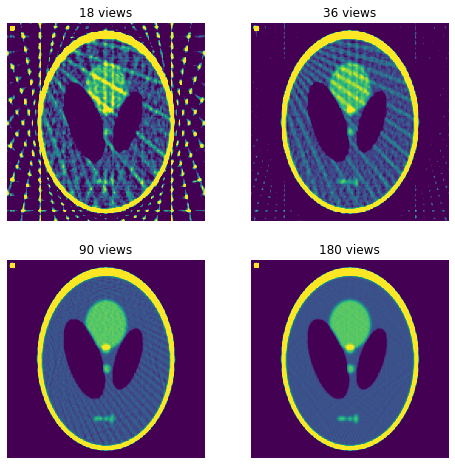

In [19]:
plt.figure(figsize=(8,8))
plt.subplot(221)
plt.title('18 views')
plt.imshow(ctSim(imm,np.arange(0,180,10),.0),vmin=0.15,vmax=0.35)
plt.axis('off')
plt.subplot(222)
plt.title('36 views')
plt.imshow(ctSim(imm,np.arange(0,180,5),.0),vmin=0.15,vmax=0.35)
plt.axis('off')
plt.subplot(223)
plt.title('90 views')
plt.imshow(ctSim(imm,np.arange(0,180,2),.0),vmin=0.15,vmax=0.35)
plt.axis('off')
plt.subplot(224)
plt.title('180 views')
plt.imshow(ctSim(imm,np.arange(0,180,1),.0),vmin=0.15,vmax=0.35)
plt.axis('off')

## Assesment:

1. Do you understand what the sinogram is showing you?
2. Does the sinogram seems noisy with the noise level you chose?
3. Is the reconstructed image noisy?

# Task 2: Compute noise Metrics with respect to the true image

1. compute the MSE (should be easy)
2. Compute the PSNR (which is the "dynamic range"?). Can also be computed with skimage.metrics.peak_signal_noise_ration
3. Compute the SSIM. Can be done using skimage.metrics.structural_similarity 

Think about the image. You can display different features selecting a different intensity window (e.g. 0.2-0.4) to see best the inner "circles". Does the image still look like it has the same noise as displayed with the full range?

If not recompute the SSIM taking this into account

In [52]:
mse = np.mean((imm-reconIm)**2)
print(mse)

0.001096270499091757


In [58]:
skimage.metrics.mean_squared_error(imm,reconIm)

0.001096270499091757

In [53]:
skimage.metrics.structural_similarity(imm,reconIm,gaussian_weights=False)

0.9636046113885682

In [59]:
10*np.log10(0.3**2/mse)

19.143247821446362

In [48]:
skimage.metrics.peak_signal_noise_ratio(imm,reconIm,data_range=0.3)

19.143247821446362

In [208]:
help (skimage.metrics.structural_similarity)

Help on function structural_similarity in module skimage.metrics._structural_similarity:

structural_similarity(im1, im2, *, win_size=None, gradient=False, data_range=None, channel_axis=None, multichannel=False, gaussian_weights=False, full=False, **kwargs)
    Compute the mean structural similarity index between two images.
    
    
    Parameters
    ----------
    im1, im2 : ndarray
        Images. Any dimensionality with same shape.
    win_size : int or None, optional
        The side-length of the sliding window used in comparison. Must be an
        odd value. If `gaussian_weights` is True, this is ignored and the
        window size will depend on `sigma`.
    gradient : bool, optional
        If True, also return the gradient with respect to im2.
    data_range : float, optional
        The data range of the input image (distance between minimum and
        maximum possible values). By default, this is estimated from the image
        data-type.
    channel_axis : int or None

In [277]:
help(skimage.metrics.simple_metrics)

Help on module skimage.metrics.simple_metrics in skimage.metrics:

NAME
    skimage.metrics.simple_metrics

FUNCTIONS
    mean_squared_error(image0, image1)
        Compute the mean-squared error between two images.
        
        Parameters
        ----------
        image0, image1 : ndarray
            Images.  Any dimensionality, must have same shape.
        
        Returns
        -------
        mse : float
            The mean-squared error (MSE) metric.
        
        Notes
        -----
        .. versionchanged:: 0.16
            This function was renamed from ``skimage.measure.compare_mse`` to
            ``skimage.metrics.mean_squared_error``.
    
    normalized_mutual_information(image0, image1, *, bins=100)
        Compute the normalized mutual information (NMI).
        
        The normalized mutual information of :math:`A` and :math:`B` is given by::
        
        ..math::
        
            Y(A, B) = \frac{H(A) + H(B)}{H(A, B)}
        
        where :math:

# Task 3: apply metrics to a number of conditions

1. Make a plot of MSE, PSNR, SSIM as a function of the noise parameter in the "CT simulator function"
2. For one value of noise level, plot the SSIM as a function of the number of angles used assuming "same radiation dose" (i.e.: if you halve the n° of angles, reduce the noise by sqrt(2)). Use n° of angles from very low to more than necessary: e.g. (5,10,20,40,80,160,320)

BTW, why square root?

In [20]:
nAng = 7
nAngStart = 5
outImmV = np.zeros(imm.shape+(nAng,))
inNoiseL = 0.02
for angIdx in range(7):
    nSamp = nAngStart*np.power(2,angIdx)
    print(nSamp)
    thetaVect = np.arange(0,180,180/nSamp)    
    outImmV[:,:,angIdx] = ctSim(imm,thetaVect,inNoiseL*np.sqrt(nSamp))

5
10
20
40
80
160
320


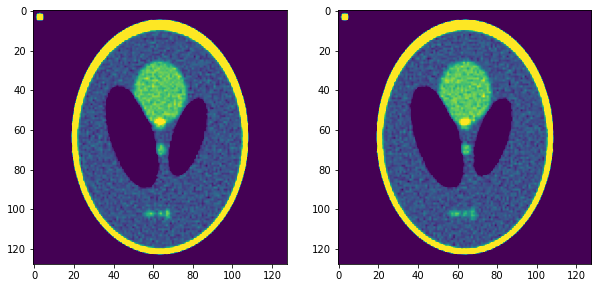

In [43]:
plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(outImmV[:,:,-1],vmin=0.15,vmax=0.35)
plt.subplot(122)
plt.imshow(outImmV[:,:,5],vmin=0.15,vmax=0.35)

In [44]:
ssimV = np.zeros((7,))
mseV = np.zeros((7,))
for idx in range(7):
    ssimV[idx] = skimage.metrics.structural_similarity(imm,outImmV[:,:,idx],data_range=0.4)
    mseV[idx] = skimage.metrics.mean_squared_error(imm,outImmV[:,:,idx])

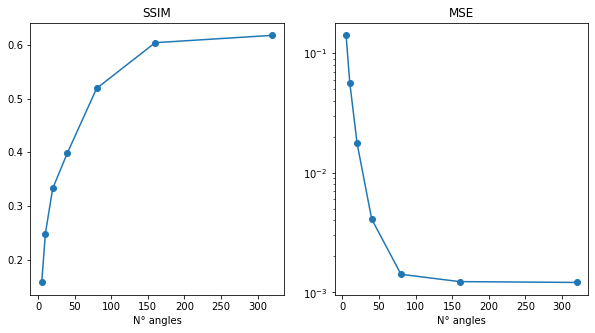

In [34]:
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(5*np.power(2,np.arange(7)),ssimV,'o-')
plt.title('SSIM')
plt.xlabel('N° angles')
plt.subplot(122)
plt.title('MSE')
plt.plot(5*np.power(2,np.arange(7)),mseV,'o-')
plt.xlabel('N° angles')
plt.yscale('log')

# Task 4: Compute noise properties of reconstructed images

Over a large number of noise realizations (how many are needed?? Start low and see) reconstruct the image and save it. Then

1. Compute the mean. What do you expect/find  and how does it compare to the reference image?
2. Compute the standard deviation over the noise realizations
3. Compute the noise power spectrum: it is defined as the average of the square of the fourier transform of every image, subtracted the mean. Why can't you compute it on one image only? Why does it look this way?

Compute the 100 samples

In [45]:
nExp = 100
resImmV = np.zeros(imm.shape+(nExp,))
for itIdx in range(nExp):
    recImm = ctSim(imm,np.arange(180),0.4)
    resImmV[:,:,itIdx] = recImm

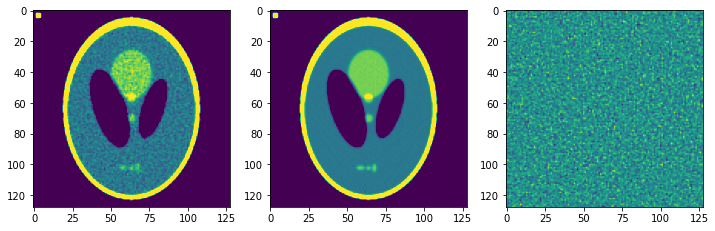

In [54]:
plt.figure(figsize=(12,6))
plt.subplot(131)
plt.imshow(resImmV[:,:,0],vmin=0.1,vmax=.35)
plt.subplot(132)
plt.imshow(np.mean(resImmV,axis=-1),vmin=0.1,vmax=.35)
plt.subplot(133)
plt.imshow(resImmV[:,:,0]-np.mean(resImmV,axis=-1)) #,vmin=0.1,vmax=.35)


Mean Image

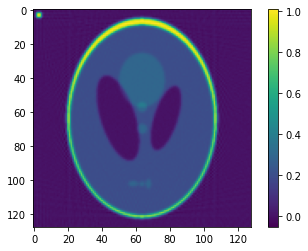

In [55]:
plt.imshow(np.mean(resImmV,axis=-1))
plt.colorbar()

Standard deviation over the 100 experiments of each pixel

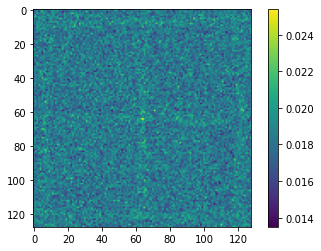

In [56]:
plt.imshow(np.std(resImmV,axis=-1))
plt.colorbar()

In [48]:
np.std(resImmV[:,:,0]-np.mean(resImmV,axis=-1))

0.018433596977029756

Noise Power Spectrum

Notice that I am using fftshift (bring frequency 0 to the centrum) to show it more clearly

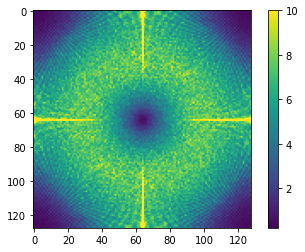

In [58]:
ftPowerSpect = np.fft.fft2(resImmV-np.expand_dims(np.mean(resImmV,axis=-1),axis=-1),axes=(0,1))
NPS = np.mean(np.abs(ftPowerSpect)**2,axis=-1)
plt.imshow(np.fft.fftshift(NPS),vmax=10)
plt.colorbar()

Plot some lines of the NPS over the x axis, y axis, diagonal

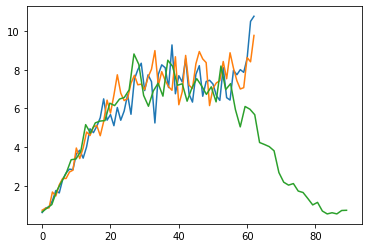

In [50]:
plt.plot(NPS[:63,1])
plt.plot(NPS[1,:63])
pDiag = np.diagonal(NPS)
pDiag = pDiag[:64]
plt.plot(np.sqrt(2)*np.arange(pDiag.shape[0]),pDiag)


In [93]:
pDiag.shape

(64,)

# Task 5: MR image simulator

Now do the same for MR. The MR coils acquire the 2D fourier transform of a signal and there (mostly) gaussian noise is present. Therefore you need to do 
signal = np.fft.fft2 (input image), signal+=noise, image = np.real(np.fft.ifft2(signal))

Compute the same metrics as before. Do not experiment (for now....) with the number of points acquired in the FT space. 

In [30]:
# Implement the FFT and Reverse FFT using rfft2, which is faster to compute for real signals

def mrSimulator (inpImm, noiseLevel, show=False):
    kSpace = np.fft.rfft2 (inpImm)
    if show:
        plt.figure()
        plt.subplot(121)
        plt.imshow(np.log(np.abs(kSpace)))
        plt.title('Original')
    # Add gaussian noise (realistic assumption!) on both the real and imaginary components of the signal
    kSpace = kSpace+np.random.normal(0,noiseLevel,kSpace.shape)+1j*np.random.normal(0,noiseLevel,kSpace.shape)
    if show:
        plt.subplot(122)
        plt.imshow(np.log(np.abs(kSpace)))
        plt.title('Original')    
    # Reconstruct the image
    recImm = np.fft.irfft2(kSpace)
    return recImm

 Try to call the function once, showing the k-space also.

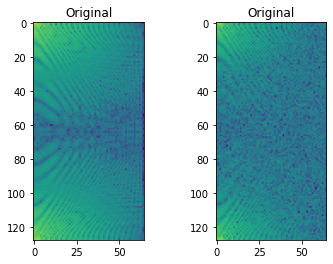

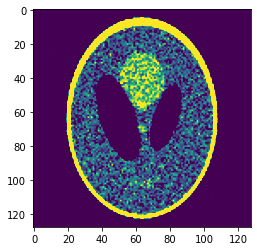

In [32]:
recImm = mrSimulator(imm,5,True)
plt.figure()
plt.imshow(recImm,vmin=0.15,vmax=0.35)

### Compute the noise power spectrum
We proceed equally as with CT

In [33]:
nExp = 100
resImmV = np.zeros(imm.shape+(nExp,))
for itIdx in range(nExp):
    recImm = mrSimulator(imm,4)
    resImmV[:,:,itIdx] = recImm

The mean image looks like the input one.

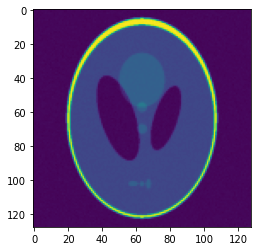

In [22]:
plt.imshow(np.mean(resImmV,axis=-1))

The standard deviation image looks as expected (flat everywhere)

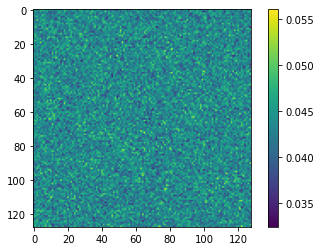

In [23]:
plt.imshow(np.std(resImmV,axis=-1))
plt.colorbar()

### Fourier Noise Power Spectrum

The noise is white. We do not see any dependency on the noise from the frequency. 

It can be expected as we added gaussian noise to the input signal already in fourier space!

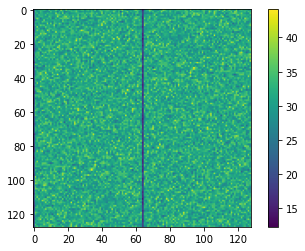

In [26]:
ftPowerSpect = np.fft.fft2(resImmV-np.expand_dims(np.mean(resImmV,axis=-1),axis=-1),axes=(0,1))
NPS = np.mean(np.abs(ftPowerSpect)**2,axis=-1)
plt.imshow(NPS)
plt.colorbar()

 Plot two lines and the diagonal. No dipendence is seen!

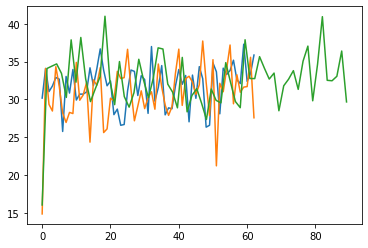

In [27]:
plt.plot(NPS[:63,1])
plt.plot(NPS[1,:63])
pDiag = np.diagonal(NPS)
pDiag = pDiag[:64]
plt.plot(np.sqrt(2)*np.arange(pDiag.shape[0]),pDiag)
